# Customer Churn Prediction in E-Commerce Industry

## Project Objective

The goal of this project is to predict which e-commerce customers are likely to churn using machine learning classification models.

### Objectives

1. To analyze customer behavior and demographic data to identify factors contributing to customer churn.
2. To perform exploratory data analysis to discover churn patterns.
3. To preprocess the dataset by handling missing values, encoding categorical variables, and scaling numerical features.
4. To develop and compare classification models such as Logistic Regression, Decision Tree, and Random Forest.
5. To evaluate model performance using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

In [ ]:
# STEP 1: IMPORT REQUIRED LIBRARIES

# Libraries for data handling
import pandas as pd
import numpy as np

# Libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Libraries for splitting and scaling data
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

# To ignore warning messages
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# STEP 2: LOAD THE DATASET

# Read the uploaded Excel file
df = pd.read_excel("E Commerce Dataset.xlsx", sheet_name="E Comm")

# Display first 5 rows
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [ ]:
# Display number of rows and columns
df.shape

(5630, 20)

In [ ]:
# Display column names, data types, and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

In [ ]:
# STEP 3: DATA UNDERSTANDING

# Display statistical summary of numerical columns
df.describe()

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5366.000000,5630.000000,5379.000000,5375.000000,5630.000000,5630.000000,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000
mean,52815.500000,0.168384,10.189899,1.654707,15.639896,2.931535,3.688988,3.066785,4.214032,0.284902,15.707922,1.751023,3.008004,4.543491,177.223030
std,1625.385339,0.374240,8.557241,0.915389,8.531475,0.721926,1.023999,1.380194,2.583586,0.451408,3.675485,1.894621,2.939680,3.654433,49.207036
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,2.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,145.770000
50%,52815.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.280000
75%,54222.750000,0.000000,16.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.392500
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,324.990000


In [ ]:
# Check missing values in each column
df.isnull().sum()

,0
CustomerID,0
Churn,0
Tenure,264
PreferredLoginDevice,0
CityTier,0
WarehouseToHome,251
PreferredPaymentMode,0
Gender,0
HourSpendOnApp,255
NumberOfDeviceRegistered,0


In [ ]:
# Check churn count
df["Churn"].value_counts()

,count
Churn,
0,4682
1,948


In [ ]:
# Check churn percentage
df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
0,83.161634
1,16.838366


In [ ]:
# STEP 4: DATA CLEANING

# Remove CustomerID because it is only an identifier
df.drop("CustomerID", axis=1, inplace=True)

# Select numerical columns
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

# Fill missing numerical values with median
for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Select categorical columns
categorical_cols = df.select_dtypes(include=["object"]).columns

# Fill missing categorical values with mode
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Check missing values after cleaning
df.isnull().sum()

,0
Churn,0
Tenure,0
PreferredLoginDevice,0
CityTier,0
WarehouseToHome,0
PreferredPaymentMode,0
Gender,0
HourSpendOnApp,0
NumberOfDeviceRegistered,0
PreferedOrderCat,0


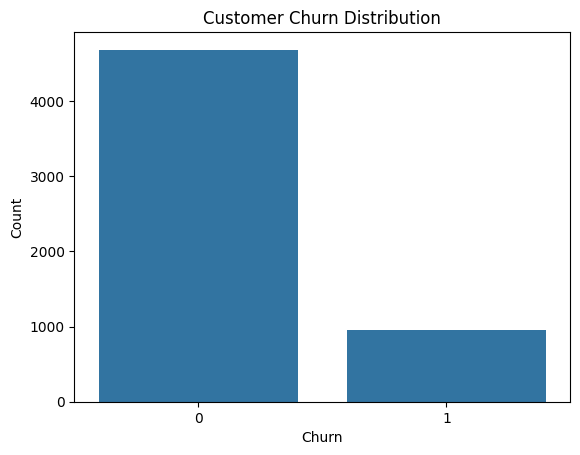

In [ ]:
# STEP 5: EDA - CUSTOMER CHURN DISTRIBUTION

# Shows how many customers churned and how many did not
sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.show()

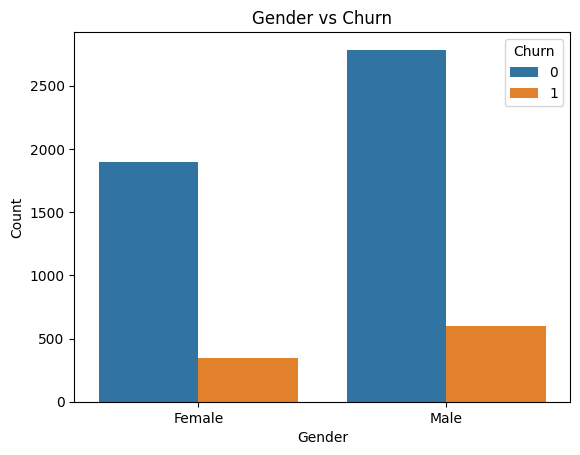

In [ ]:
# STEP 6: EDA - GENDER VS CHURN

# Compare churn between male and female customers
sns.countplot(x="Gender", hue="Churn", data=df)

plt.title("Gender vs Churn")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

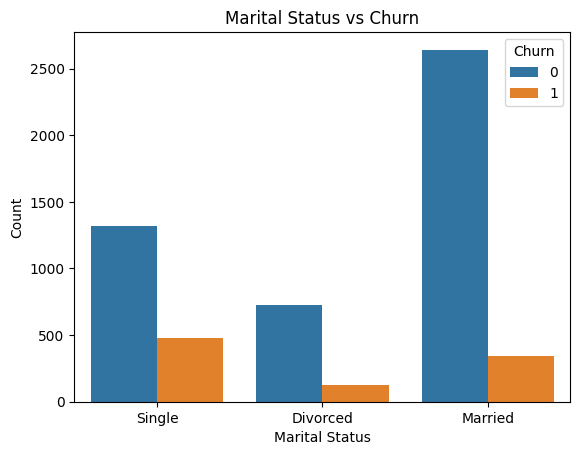

In [ ]:
# STEP 7: EDA - MARITAL STATUS VS CHURN

# Check whether marital status affects churn
sns.countplot(x="MaritalStatus", hue="Churn", data=df)

plt.title("Marital Status vs Churn")
plt.xlabel("Marital Status")
plt.ylabel("Count")

plt.show()

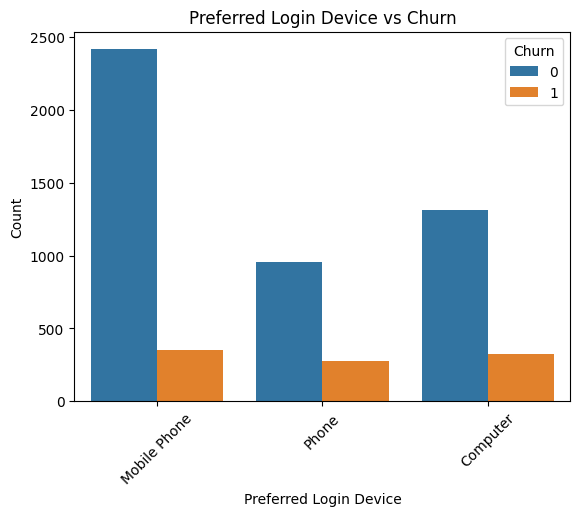

In [ ]:
# STEP 8: EDA - PREFERRED LOGIN DEVICE VS CHURN

# Analyze churn based on customer's preferred login device
sns.countplot(x="PreferredLoginDevice", hue="Churn", data=df)

plt.title("Preferred Login Device vs Churn")
plt.xlabel("Preferred Login Device")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

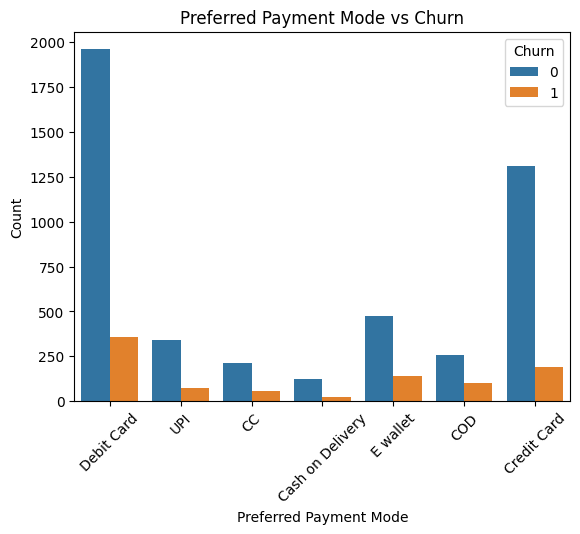

In [ ]:
# STEP 9: EDA - PREFERRED PAYMENT MODE VS CHURN

# Analyze churn based on preferred payment method
sns.countplot(x="PreferredPaymentMode", hue="Churn", data=df)

plt.title("Preferred Payment Mode vs Churn")
plt.xlabel("Preferred Payment Mode")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

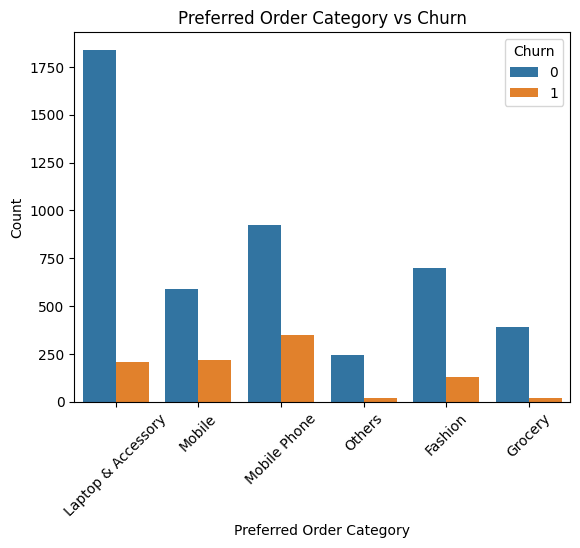

In [ ]:
# STEP 10: EDA - PREFERRED ORDER CATEGORY VS CHURN

# Analyze churn across different product categories
sns.countplot(x="PreferedOrderCat", hue="Churn", data=df)

plt.title("Preferred Order Category vs Churn")
plt.xlabel("Preferred Order Category")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

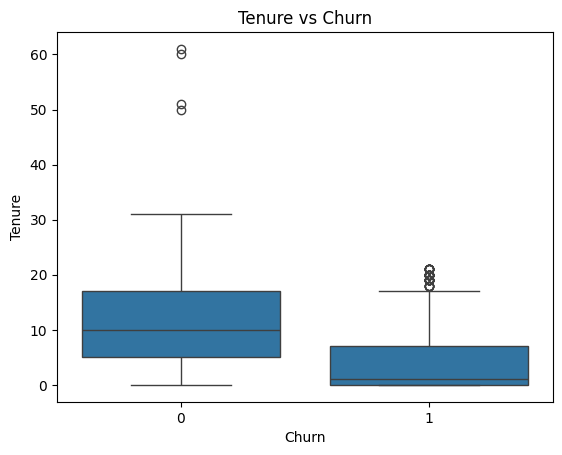

In [ ]:
# STEP 11: EDA - TENURE VS CHURN

# Compare tenure of churned and retained customers
sns.boxplot(x="Churn", y="Tenure", data=df)

plt.title("Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure")

plt.show()

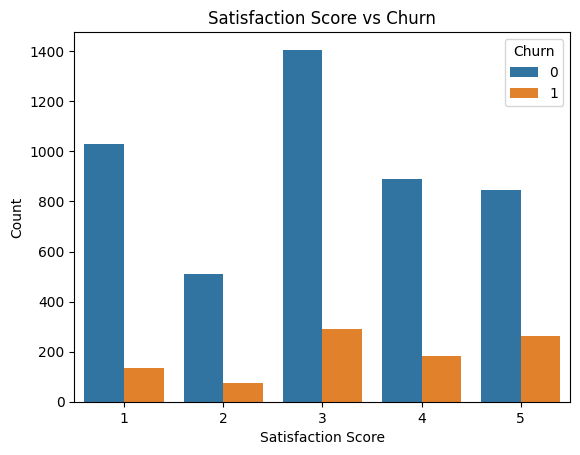

In [ ]:
# STEP 12: EDA - SATISFACTION SCORE VS CHURN

# Analyze relationship between satisfaction score and churn
sns.countplot(x="SatisfactionScore", hue="Churn", data=df)

plt.title("Satisfaction Score vs Churn")
plt.xlabel("Satisfaction Score")
plt.ylabel("Count")

plt.show()

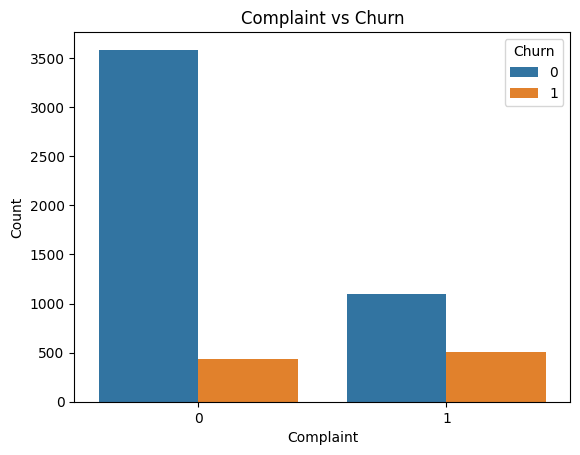

In [ ]:
# STEP 13: EDA - COMPLAINT VS CHURN

# Check if customers who complained are more likely to churn
sns.countplot(x="Complain", hue="Churn", data=df)

plt.title("Complaint vs Churn")
plt.xlabel("Complaint")
plt.ylabel("Count")

plt.show()

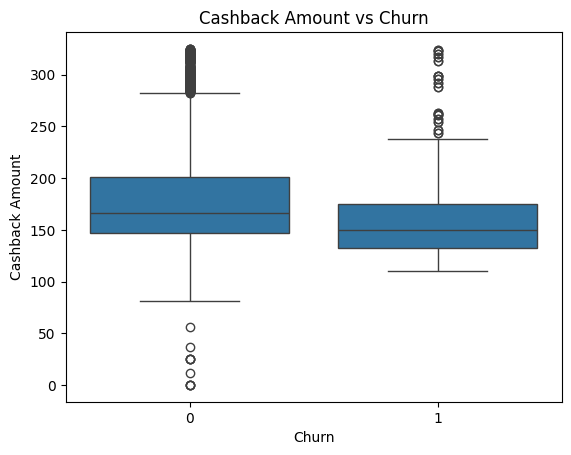

In [ ]:
# STEP 14: EDA - CASHBACK AMOUNT VS CHURN

# Compare cashback received by churned and retained customers
sns.boxplot(x="Churn", y="CashbackAmount", data=df)

plt.title("Cashback Amount vs Churn")
plt.xlabel("Churn")
plt.ylabel("Cashback Amount")

plt.show()

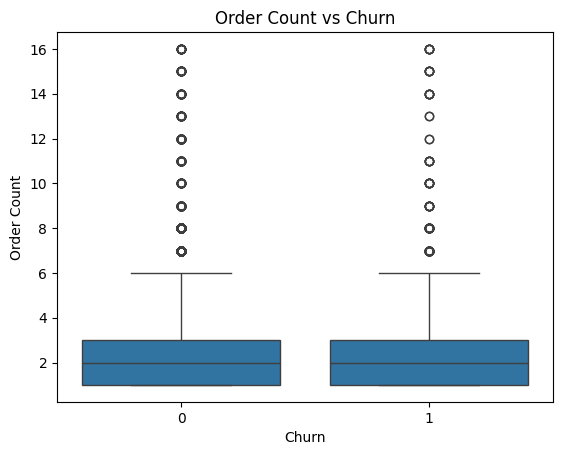

In [ ]:
# STEP 15: EDA - ORDER COUNT VS CHURN

# Compare order count of churned and retained customers
sns.boxplot(x="Churn", y="OrderCount", data=df)

plt.title("Order Count vs Churn")
plt.xlabel("Churn")
plt.ylabel("Order Count")

plt.show()

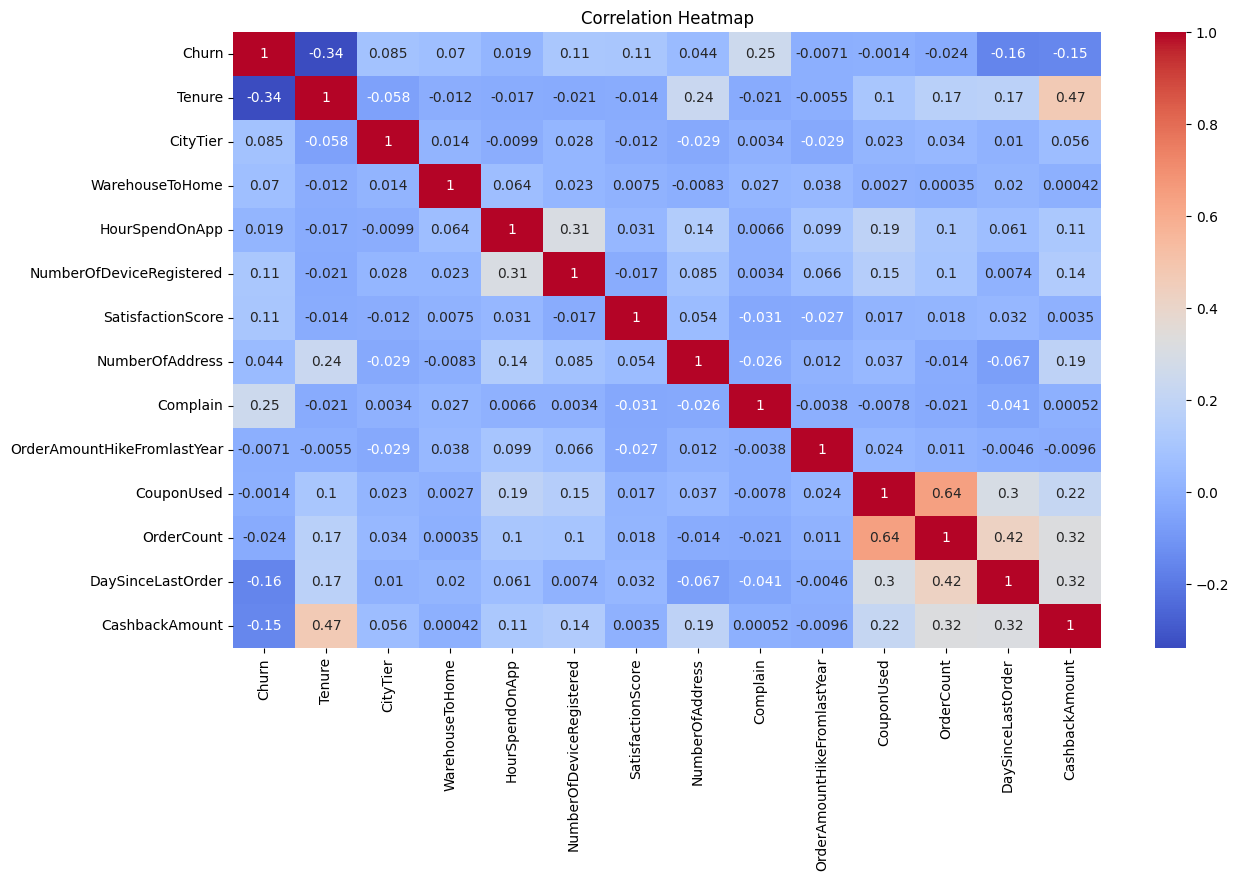

In [ ]:
# STEP 16: CORRELATION HEATMAP

# Correlation shows relationship between numerical variables
plt.figure(figsize=(14, 8))

sns.heatmap(df.select_dtypes(include=np.number).corr(),annot=True,cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
# STEP 17: ENCODE CATEGORICAL VARIABLES

# Convert categorical columns into numerical dummy variables
df_encoded = pd.get_dummies(df, drop_first=True)

# Display encoded dataset
df_encoded.head()

,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,...,PreferredPaymentMode_E wallet,PreferredPaymentMode_UPI,Gender_Male,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single
0,1,4.0,3,6.0,3.0,3,2,9,1,11.0,...,False,False,False,False,True,False,False,False,False,True
1,1,9.0,1,8.0,3.0,4,3,7,1,15.0,...,False,True,True,False,False,True,False,False,False,True
2,1,9.0,1,30.0,2.0,4,3,6,1,14.0,...,False,False,True,False,False,True,False,False,False,True
3,1,0.0,3,15.0,2.0,4,5,8,0,23.0,...,False,False,True,False,True,False,False,False,False,True
4,1,0.0,1,12.0,3.0,3,5,3,0,11.0,...,False,False,True,False,False,True,False,False,False,True


In [ ]:
# Display shape after encoding
df_encoded.shape

(5630, 30)

In [ ]:
# STEP 18: DEFINE FEATURES AND TARGET

# X contains all independent variables
X = df_encoded.drop("Churn", axis=1)

# y contains the target variable
y = df_encoded["Churn"]

In [ ]:
# STEP 19: TRAIN-TEST SPLIT

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

In [ ]:
# Check training and testing feature shapes
X_train.shape, X_test.shape

((4504, 29), (1126, 29))

In [ ]:
# Check training and testing target shapes
y_train.shape, y_test.shape

((4504,), (1126,))

In [ ]:
# STEP 20: FEATURE SCALING

# Scaling is mainly required for Logistic Regression
scaler = StandardScaler()

# Fit scaler on training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform testing data using same scaler
X_test_scaled = scaler.transform(X_test)

In [ ]:
# STEP 21: LOGISTIC REGRESSION MODEL

# Create Logistic Regression model
lr_model = LogisticRegression(max_iter=1000)

# Train the model
lr_model.fit(X_train_scaled, y_train)

# Predict churn values
lr_pred = lr_model.predict(X_test_scaled)

# Predict churn probabilities
lr_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

In [ ]:
# STEP 22: DECISION TREE MODEL

# Create Decision Tree model
dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

# Train the model
dt_model.fit(X_train, y_train)

# Predict churn values
dt_pred = dt_model.predict(X_test)

# Predict churn probabilities
dt_prob = dt_model.predict_proba(X_test)[:, 1]

In [ ]:
# STEP 23: RANDOM FOREST MODEL

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

# Predict churn values
rf_pred = rf_model.predict(X_test)

# Predict churn probabilities
rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [ ]:
# STEP 24: MODEL EVALUATION FUNCTION

# Function to calculate all model evaluation metrics
def evaluate_model(model_name, y_test, y_pred, y_prob):

    print("\n===================================")
    print(model_name)
    print("===================================")

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

In [ ]:
# STEP 25: EVALUATE ALL MODELS

# Evaluate Logistic Regression
evaluate_model("Logistic Regression", y_test, lr_pred, lr_prob)

# Evaluate Decision Tree
evaluate_model("Decision Tree", y_test, dt_pred, dt_prob)

# Evaluate Random Forest
evaluate_model("Random Forest", y_test, rf_pred, rf_prob)


Logistic Regression
Accuracy: 0.88898756660746
Precision: 0.7443609022556391
Recall: 0.5210526315789473
F1 Score: 0.6130030959752322
ROC-AUC: 0.8872863247863247

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.96      0.94       936
           1       0.74      0.52      0.61       190

    accuracy                           0.89      1126
   macro avg       0.83      0.74      0.77      1126
weighted avg       0.88      0.89      0.88      1126


Decision Tree
Accuracy: 0.8934280639431617
Precision: 0.7777777777777778
Recall: 0.5157894736842106
F1 Score: 0.620253164556962
ROC-AUC: 0.8827682186234819

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94       936
           1       0.78      0.52      0.62       190

    accuracy                           0.89      1126
   macro avg       0.84      0.74      0.78      1126
weighted avg       0.89      0.89 

In [ ]:
# STEP 26: MODEL COMPARISON TABLE

# Compare all models using evaluation metrics
results = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],

    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred)
    ],

    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred)
    ],

    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred)
    ],

    "ROC-AUC": [
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, dt_prob),
        roc_auc_score(y_test, rf_prob)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.888988,0.744361,0.521053,0.613003,0.887286
1,Decision Tree,0.893428,0.777778,0.515789,0.620253,0.882768
2,Random Forest,0.978686,0.988235,0.884211,0.933333,0.999294


In [ ]:
# STEP 27: BEST MODEL SELECTION

# Select the best model based on ROC-AUC score
best_model = results.sort_values(
    by="ROC-AUC",
    ascending=False
).iloc[0]

best_model

,2
Model,Random Forest
Accuracy,0.978686
Precision,0.988235
Recall,0.884211
F1 Score,0.933333
ROC-AUC,0.999294


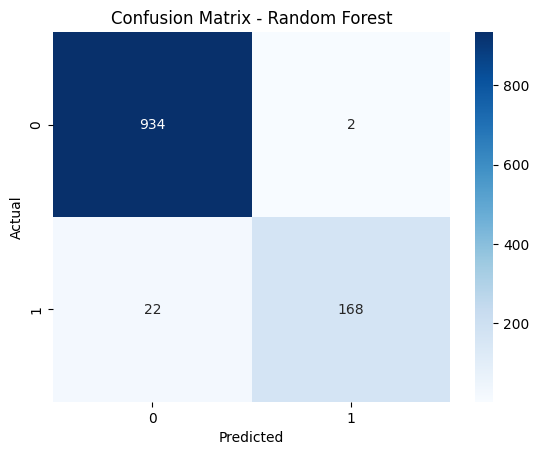

In [ ]:
# STEP 28: CONFUSION MATRIX

# Confusion matrix for Random Forest model
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

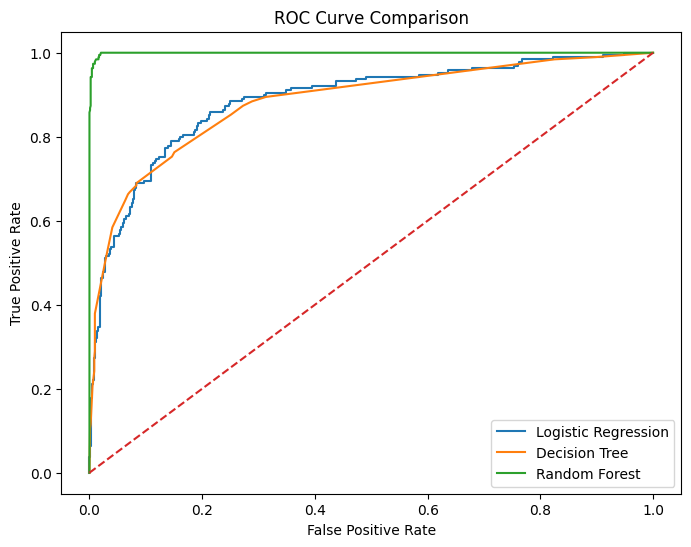

In [ ]:
# STEP 29: ROC CURVE COMPARISON

# Calculate ROC values for all models
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)

plt.figure(figsize=(8, 6))

plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot(fpr_dt, tpr_dt, label="Decision Tree")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")

# Diagonal line represents random guessing
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

In [ ]:
# STEP 30: FEATURE IMPORTANCE TABLE

# Get feature importance from Random Forest
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

# Sort features by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display top 10 important features
feature_importance.head(10)

,Feature,Importance
0,Tenure,0.201865
12,CashbackAmount,0.103427
2,WarehouseToHome,0.071621
7,Complain,0.063382
11,DaySinceLastOrder,0.061224
6,NumberOfAddress,0.060512
8,OrderAmountHikeFromlastYear,0.058412
5,SatisfactionScore,0.050605
4,NumberOfDeviceRegistered,0.038300
10,OrderCount,0.031455


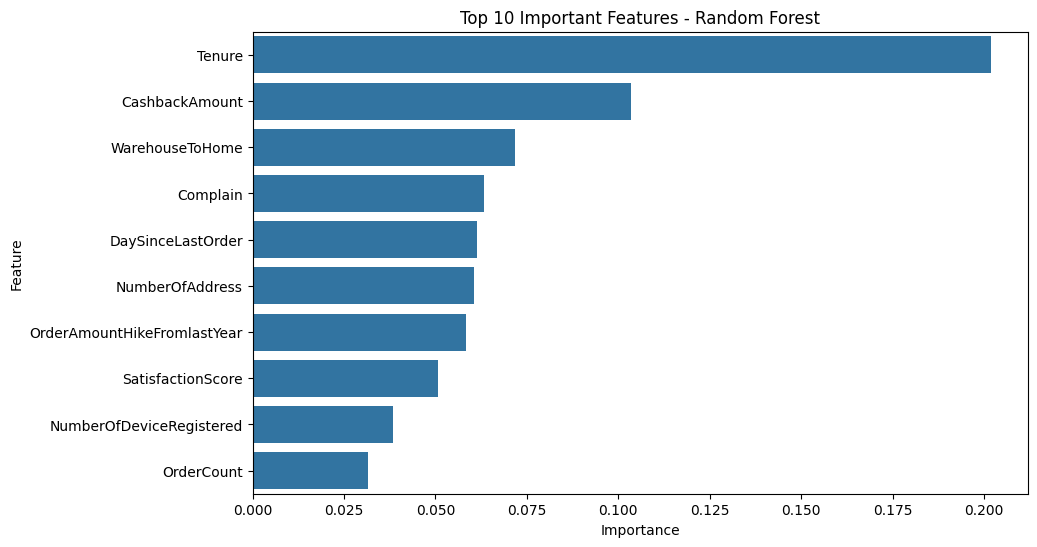

In [ ]:
# STEP 31: FEATURE IMPORTANCE GRAPH

# Visualize top 10 important features
plt.figure(figsize=(10, 6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance.head(10)
)

plt.title("Top 10 Important Features - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [ ]:
# STEP 32: FINAL BUSINESS CONCLUSION

print("""
Business Conclusion:

This project predicts whether an e-commerce customer is likely to churn or not.

The models used are:
1. Logistic Regression
2. Decision Tree
3. Random Forest

The models were evaluated using:
Accuracy, Precision, Recall, F1 Score, and ROC-AUC.

For customer churn prediction, Recall is very important because the business wants to correctly identify customers who are likely to leave.

Important factors affecting churn may include:
1. Tenure
2. Complaint status
3. Satisfaction score
4. Order count
5. Cashback amount
6. Day since last order
7. Preferred order category

The best model should be selected based on ROC-AUC, Recall, and F1 Score.
""")


Business Conclusion:

This project predicts whether an e-commerce customer is likely to churn or not.

The models used are:
1. Logistic Regression
2. Decision Tree
3. Random Forest

The models were evaluated using:
Accuracy, Precision, Recall, F1 Score, and ROC-AUC.

For customer churn prediction, Recall is very important because the business wants to correctly identify customers who are likely to leave.

Important factors affecting churn may include:
1. Tenure
2. Complaint status
3. Satisfaction score
4. Order count
5. Cashback amount
6. Day since last order
7. Preferred order category

The best model should be selected based on ROC-AUC, Recall, and F1 Score.

